In [1]:
import numpy as np
import bilby
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
import json
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib import rc
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
default_kwargs = dict(
    bins=100,
    smooth=2,
    smooth1d=2,

    title_fmt='.1f',
    title_kwargs=dict(fontsize=18, pad=2),
    label_kwargs=dict(color='black', fontsize=18),

    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_density=False,
    plot_datapoints=False,
    max_n_ticks=3,
    labelpad=-0.02
)

In [4]:
cosmo_corner_lbs = [r'$H_0\,[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$',
              r'$\Omega_{m,0}$', 
              r'$\gamma$', 
              r'$\kappa$', 
              r'$z_p$']
cosmo_title_labels = [r'$H_0$',
              r'$\Omega_{m,0}$', 
              r'$\gamma$', 
              r'$\kappa$', 
              r'$z_p$']

In [5]:
def plot_corner(data, ref_data, label, injected_values, labels=cosmo_corner_lbs, title_labels=cosmo_title_labels, lbl_size=16):
    figure = corner.corner(ref_data, 
                           titles = title_labels, labels = labels,
                           color=ska_color_intermediate, alpha=0.5,
                           range=[(40, 100), (0, 1), (1.5, 6.5), (0, 9.5), (0.5, 1.8)],  # one tuple per parameter
                           rect=[0, 0, 1, 1], 
                           show_titles=False,
                           quantiles=None,      
                           hist_kwargs={"alpha": 0.45, "linewidth": 2.},
                           contour_kwargs={"alpha": 0.45},
                           fill_contours=False,
                           figsize=(6,4), **default_kwargs)
    corner.corner(data, 
                           titles = title_labels, labels = labels,
                           color=ska_color_purple,
                           truths = injected_values,
                           truth_color=ska_color_pink,
                           truth_kwargs={"linewidth": 3.5},
                           fill_contours=True,
                           show_titles=True,
                           title_quantiles=[0.16, 0.5, 0.84],
                           quantiles=[0.16, 0.84],
                           hist_kwargs={"linewidth": 2.},
                           range=[(40, 100), (0, 1), (1.5, 6.5), (0, 9.5), (0.5, 1.8)],  # one tuple per parameter
                           rect=[0, 0, 1, 1], 
                           fig=figure, **default_kwargs)
    for ax in figure.get_axes():
        ax.tick_params(axis = 'both', labelsize = lbl_size)

    figure.subplots_adjust(wspace=0, hspace=0)
    legend_elements = [
        Line2D(
        [0], [0],
        color=ska_color_pink,
        lw=3.5,
        linestyle="solid",
        label=r"\rm Injected value"
    ),
    Patch(facecolor=ska_color_purple, label=r"\rm Clustered GWs - {\textrm{H\textsc{i}}}", alpha=1),
    Patch(facecolor='none', edgecolor=ska_color_intermediate, linewidth=2.5, label=r"\rm Clustered GWs - No {\textrm{H\textsc{i}}}", alpha=0.45),
    ]

    figure.legend(handles=legend_elements, bbox_to_anchor=(0.95, 0.8), fontsize=18, frameon=False)
    plt.subplots_adjust(left=0.2, bottom=0.2, right=0.95, top=0.95)
    plt.savefig(f'corner_{label}.pdf', bbox_inches='tight')
    plt.show()

In [6]:
params = ['H0', 'Om0', 'gamma', 'kappa', 'zp']
injected_values = [67.7, 0.308, 2.7, 6, 1]

In [ ]:
headline_result = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs1_nside16_HIHI/label_result.json')
no_hi_reference = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs10_nside16_HINoHI/label_result.json')

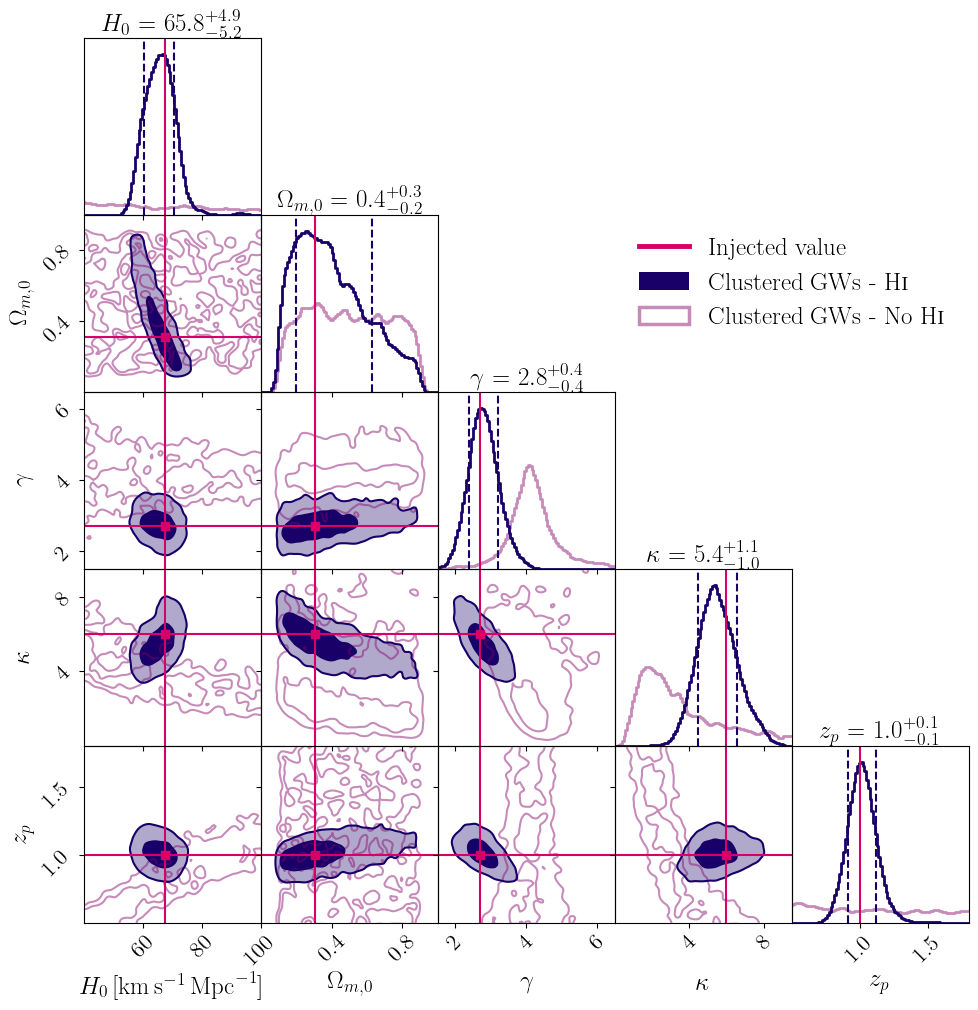

In [8]:
fig = plot_corner(headline_result.posterior[params], no_hi_reference.posterior[params], 'headline', injected_values)

In [9]:
np.median(headline_result.posterior['H0']), np.median(no_hi_reference.posterior['H0'])

(65.78793487917277, 85.47633705823573)

In [10]:
# take the 1sigma interval
sorted_data = np.sort(headline_result.posterior['H0'])
median = np.median(sorted_data)
lower_sigma1 = np.percentile(sorted_data, 15.865)
upper_sigma1 = np.percentile(sorted_data, 84.135)
print(np.round(median, 2), np.round(median - lower_sigma1,2), np.round(upper_sigma1 - median,2))

65.79 5.23 4.97


In [11]:
# take the 1sigma interval
sorted_data = np.sort(no_hi_reference.posterior['H0'])
median = np.median(sorted_data)
lower_sigma2 = np.percentile(sorted_data, 15.865)
upper_sigma2 = np.percentile(sorted_data, 84.135)
print(np.round(median, 2), np.round(median - lower_sigma2,2), np.round(upper_sigma2 - median,2))

85.48 57.23 95.4


In [12]:
# percentage improvement
# Calculate average uncertainties
sigma1 = (upper_sigma1 - lower_sigma1) / 2
sigma2 = (upper_sigma2 - lower_sigma2) / 2

print('sigma1:', sigma1)
print('sigma2:', sigma2)
# Calculate improvement as relative decrease in uncertainty from second to first
improvement = (sigma2 - sigma1) / sigma2 * 100
print(improvement)

sigma1: 5.100062056537983
sigma2: 76.31376001756884
93.3169823432054


In [13]:
# precision of headline result
# take the 1sigma interval
sorted_data = np.sort(headline_result.posterior['H0'])
median = np.median(sorted_data)
lower_sigma1 = np.percentile(sorted_data, 15.865)
upper_sigma1 = np.percentile(sorted_data, 84.135)
print('Precision = ', (upper_sigma1-lower_sigma1)/2/median*100)

Precision =  7.752275650398273
